# 모듈 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# KNN 알고리즘 분류기(classifier) 클래스
from sklearn.neighbors import KNeighborsClassifier

# 데이터 준비

In [2]:
file_path = 'https://bit.ly/fish_csv_data'

In [3]:
fish = pd.read_csv(file_path)

In [4]:
fish # 무게 길이 대각선 높이  두께

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [5]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


# 데이터 탐색

## 카테고리 변수 탐색

In [6]:
fish.Species.value_counts() # 물고기 종류 빈도수

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


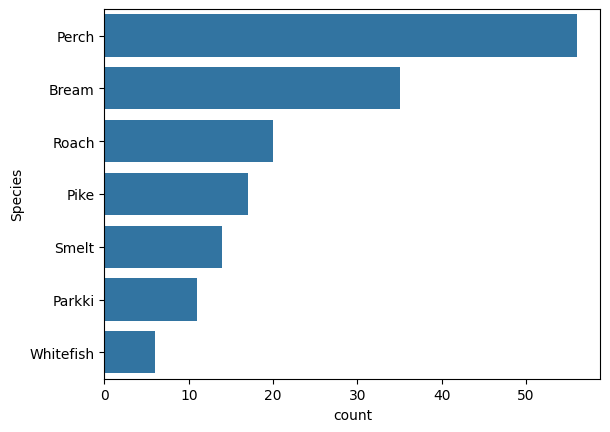

In [7]:
sns.countplot(data=fish,y='Species',order=fish.Species.value_counts().index)
plt.show()

## 연속형 자료들 탐색

In [8]:
fish.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


연속형 변수들의 histogram과 boxplot을 시각화

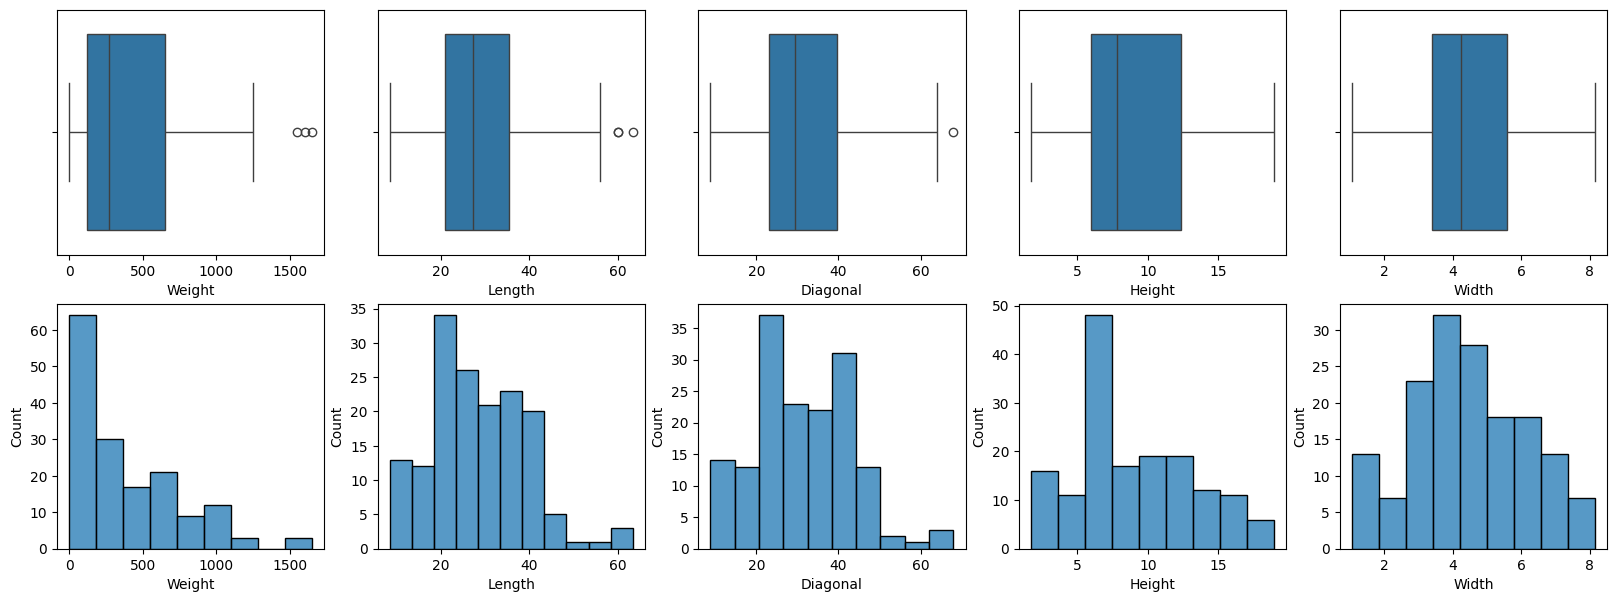

In [9]:
fig,axes=plt.subplots(nrows=2,ncols=5,figsize=(20,7))

sns.boxplot(data=fish,x=fish.Weight,ax=axes[0][0])
sns.boxplot(data=fish,x=fish.Length,ax=axes[0][1])
sns.boxplot(data=fish,x=fish.Diagonal,ax=axes[0][2])
sns.boxplot(data=fish,x=fish.Height,ax=axes[0][3])
sns.boxplot(data=fish,x=fish.Width,ax=axes[0][4])
sns.histplot(data=fish,x=fish.Weight,ax=axes[1][0])
sns.histplot(data=fish,x=fish.Length,ax=axes[1][1])
sns.histplot(data=fish,x=fish.Diagonal,ax=axes[1][2])
sns.histplot(data=fish,x=fish.Height,ax=axes[1][3])
sns.histplot(data=fish,x=fish.Width,ax=axes[1][4])


plt.show()

In [10]:
features=fish.columns[1:]

In [11]:
print(features)

Index(['Weight', 'Length', 'Diagonal', 'Height', 'Width'], dtype='object')


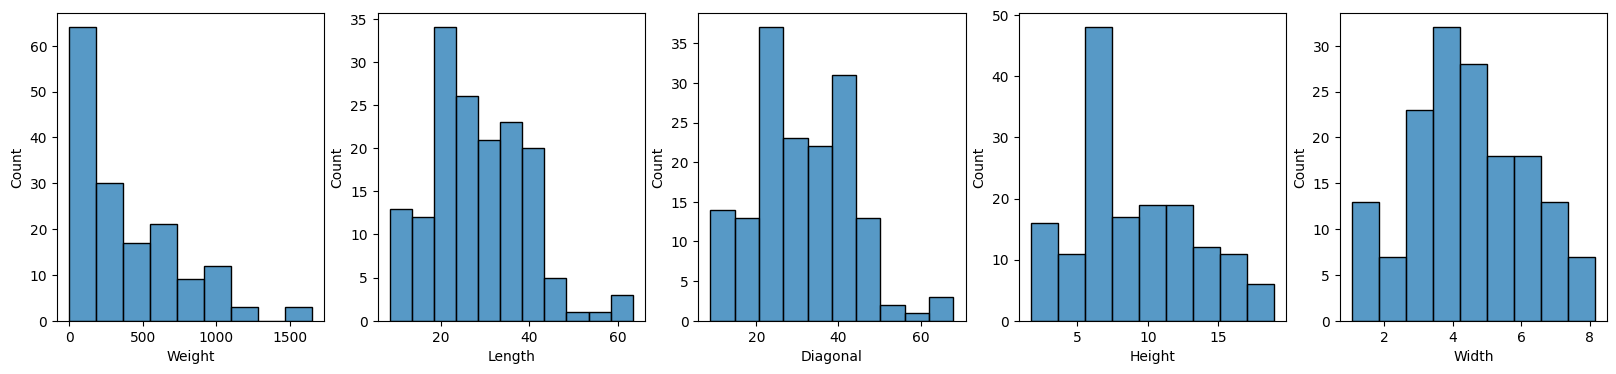

In [12]:
fig,axes=plt.subplots(ncols=5,figsize=(20,4))

for i, var in enumerate(features):
  # print(i,var)
  sns.histplot(data=fish,x=var,ax=axes[i])

plt.show()

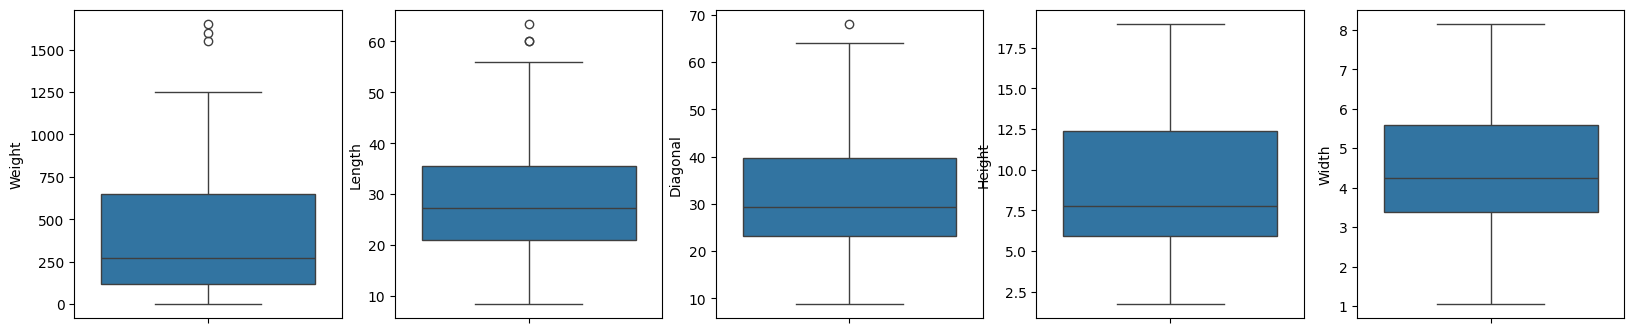

In [13]:
fig,axes=plt.subplots(ncols=5,figsize=(20,4))

for i, var in enumerate(features):
  # print(i,var)
  sns.boxplot(data=fish,y=var,ax=axes[i])

plt.show()

## 변수들 간의 상관관계 시각화

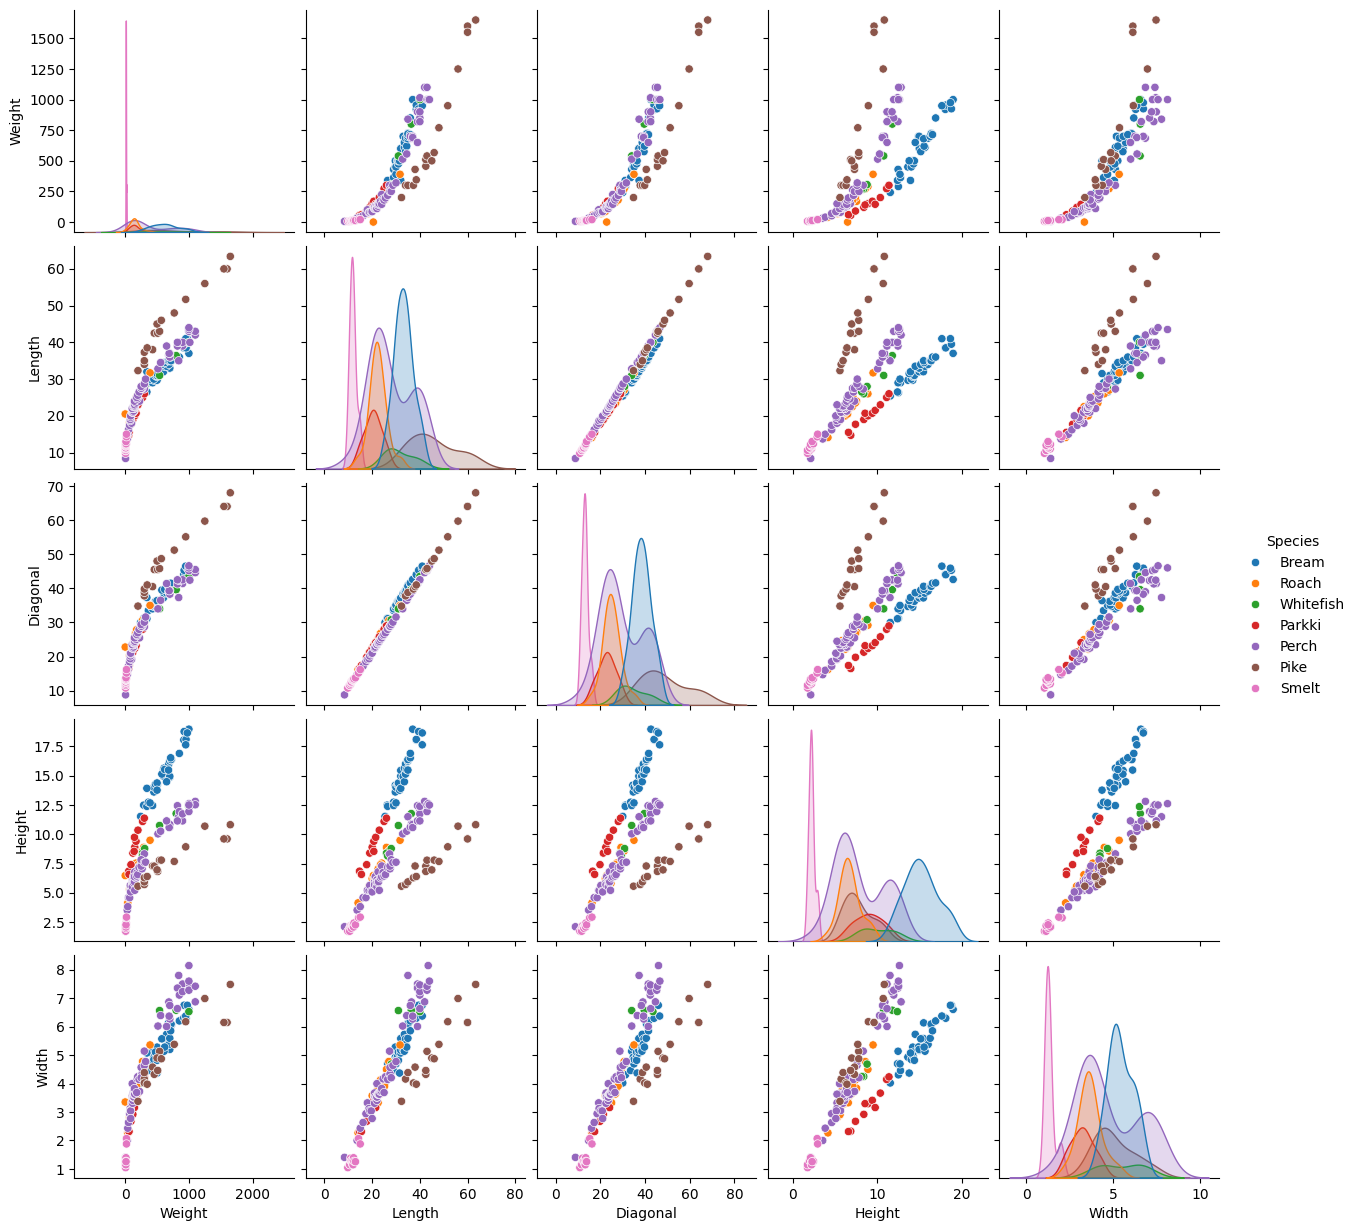

In [14]:
sns.pairplot(data=fish,hue='Species')
plt.show()

# 문제 정의

물고기의 무게와 길이를 알면 물고기의 종류(도미/빙어)를 예측할 수 있을까?
*   변수(무게,길이) 이진분류(두종류)
*   2개 변수를 사용한 이진분류(binary classification) 문제
    *   feature(특성, 변수) - Weight(무게), Length(길이) (변수-다양하다)
        *   컬럼=변수
    *   label(class,target) - 도미Bream, 빙어Smelt (변수-카테고리)    

In [15]:
df = fish.loc[fish.Species.isin(['Bream','Smelt']),['Species','Weight','Length']]# 브림스멜트 인덱스


In [16]:
# Jupyter 노트북에서 데이터프레임을 출력할 때 최대 행의 개수를 10개로 제한.
pd.set_option('display.max_rows',10)

In [17]:
df

,Species,Weight,Length
0,Bream,242.0,25.4
1,Bream,290.0,26.3
2,Bream,340.0,26.5
3,Bream,363.0,29.0
4,Bream,430.0,29.0
...,...,...,...
154,Smelt,12.2,12.2
155,Smelt,13.4,12.4
156,Smelt,12.2,13.0
157,Smelt,19.7,14.3


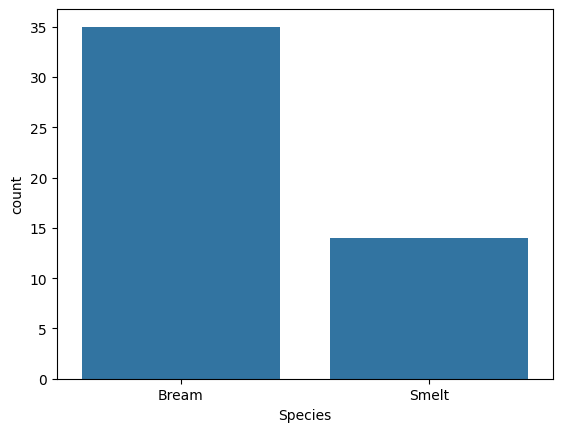

In [18]:
sns.countplot(data=df,x='Species')
plt.show() #어종2개확인차

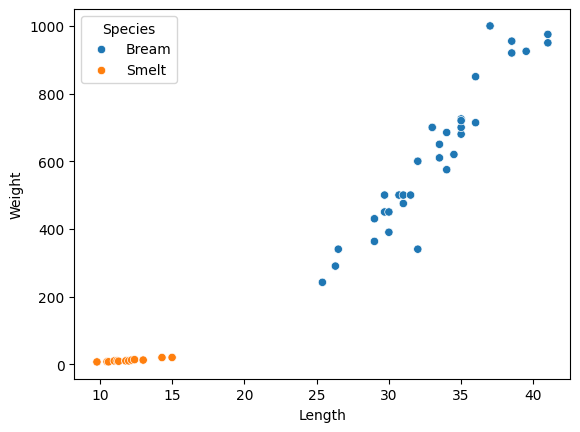

In [19]:
sns.scatterplot(data=df,x='Length',y='Weight',hue='Species')
plt.show()

scikit-learn 패키지의 머신러닝 알고리즘들은 데이터(feature)와 타겟(label) 배열을 구분해서 사용함.

특성 배열은 2차원 배열, 타겟 배열은 1차원 배열.

In [20]:
# 특성(feature) 배열 - 2d array
x = df[['Weight','Length']].values
x[:5,:]

array([[242. ,  25.4],
       [290. ,  26.3],
       [340. ,  26.5],
       [363. ,  29. ],
       [430. ,  29. ]])

In [21]:
# 타겟(target) 배열 -1d array
y= df.Species.values
y

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt',
       'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt', 'Smelt'],
      dtype=object)

# KNN 모델 훈련(학습)

KNN(K-Nearest Neighbors, K-최근접 이웃) 알고리즘:

*   K개의 가장 가까운 이웃들의 레이블을 사용해서 예측(분류)하는 머신러닝 알고리즘.
*   KNN 분류 알고리즘은 훈련(train) 시간이 필요하지 않음.
*   KNN 분류 알고리즘은 예측 시간이 오래 걸릴 수 있다.
    * 훈련 데이터와 테스트 데이터 사이의 거리들을 계산한 후에 가장 가까운 K개의 거리를 찾기 때문에 오래 걸릴 수 있다.

In [22]:
# KNN 분류 알고리즘을 구현한 객체를 생성
knn_clf = KNeighborsClassifier()

In [23]:
# KNN 모델을 훈련 - 컴퓨터에게 레이블이 있는 특성들을 제공.
knn_clf.fit(x,y) # 특성, 타겟 // 다수결

KNeighborsClassifier()

In [24]:
# 훈련된 KNN 모델로 예측.
predictions =knn_clf.predict(x)#특성
print(predictions)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Smelt'
 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt' 'Smelt'
 'Smelt' 'Smelt' 'Smelt' 'Smelt']


In [25]:
# 실젯값과 예측값을 비교
y==predictions

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [26]:
knn_clf.score(x,y) # 정확도 (accuracy)

1.0

# 가상의 물고기 데이터의 예측값

(600g, 30cm), (50g, 14cm) 물고기 데이터

In [27]:
x_test = np.array([[600,30],[50,14]])
x_test

array([[600,  30],
       [ 50,  14]])

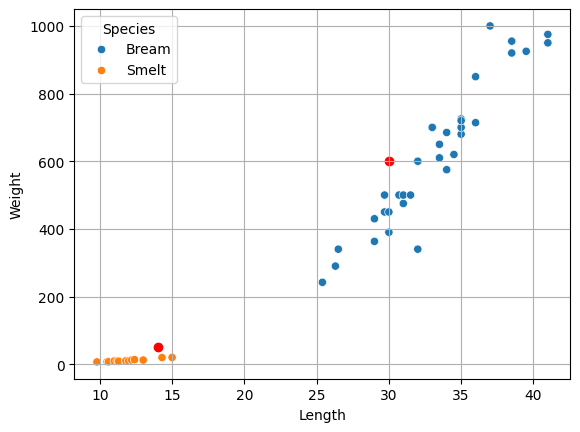

In [28]:
# 훈련 셋과 테스트 셋을 함께 시각화
sns.scatterplot(data=df, x='Length',y='Weight',hue='Species')

plt.scatter(x=x_test[:, 1],y=x_test[:,0],color='red',marker='o')

plt.grid()
plt.show() # 훈련 셋(35도미, 14빙어)

In [29]:
# 가상의 물고기들(테스트 셋)의 예측값
test_predict=knn_clf.predict(X=x_test)
print(test_predict)

['Bream' 'Smelt']


In [30]:
# KNN 모델이 찾은 k개의 가장 가까운 이웃들(k-nearest neighbors)
distances, indices=knn_clf.kneighbors(X=x_test)
# 리턴값 distances: k개의 가장 가까운 이웃까지의 거리들.
# 리턴값 indices: k개의 가장 가까운 이웃의 인덱스들.

In [31]:
print(indices)

[[15 14 18 22 20]
 [48 47 45 46 44]]


In [32]:
# 첫번째 테스트 물고기 (600, 30)에서 가장 가까운 5개의 훈련 셋 안의 물고기
x[indices[0]] # 변수안

array([[600. ,  32. ],
       [600. ,  32. ],
       [610. ,  33.5],
       [620. ,  34.5],
       [575. ,  34. ]])

In [33]:
print(distances)

[[ 2.          2.         10.59481005 20.5        25.3179778 ]
 [30.11660671 30.30148511 36.63495598 37.8132252  37.84283287]]


In [34]:
y[indices[0]] # 타겟안  //  첫번째 테스트 물고기 예측값을 알아내기 위해 사용한 레이블들

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

In [35]:
# 두번째 테스트 물고기(50, 14)에서 가장 가까운 5개의 훈련 셋 안의 물고기
x[indices[1]]

array([[19.9, 15. ],
       [19.7, 14.3],
       [13.4, 12.4],
       [12.2, 13. ],
       [12.2, 12.2]])

# k 값에 따른 정확도 변화(나중에 하이퍼파라미터)

In [40]:
predict=knn.predict(x)
predict

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream',
       'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream', 'Bream'],
      dtype=object)

In [41]:
y==predict

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [36]:
k_values =np.arange(1,50) # 현재 데이터에있는 갯수  //  가장가까운 이웃들의 개수로 사용할 배열
accuracies = [] # k 값에 따른 정확도들을 저장할 리스트.

for k in k_values:
  # KNN 분류기 객체 생성
  knn = KNeighborsClassifier(n_neighbors=k)
  # KNN 분류기 모델 훈련
  knn.fit(x,y)
  # 훈련 셋 예측값의 정확도
  acc=knn.score(x,y)
  accuracies.append(acc)
accuracies

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9795918367346939,
 1.0,
 0.9795918367346939,
 0.9795918367346939,
 0.9795918367346939,
 0.9795918367346939,
 0.9795918367346939,
 0.9795918367346939,
 0.9795918367346939,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143,
 0.7142857142857143]

In [48]:
# accuracies

AttributeError: 'list' object has no attribute 'list'

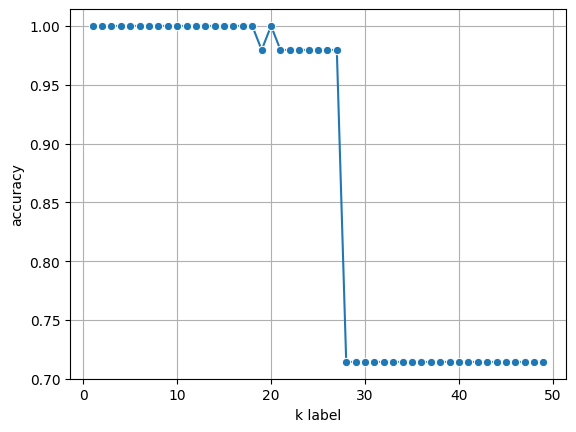

In [39]:
sns.lineplot(x=k_values,y=accuracies,marker='o')
plt.xlabel('k label')
plt.ylabel('accuracy')
plt.grid()
plt.show()

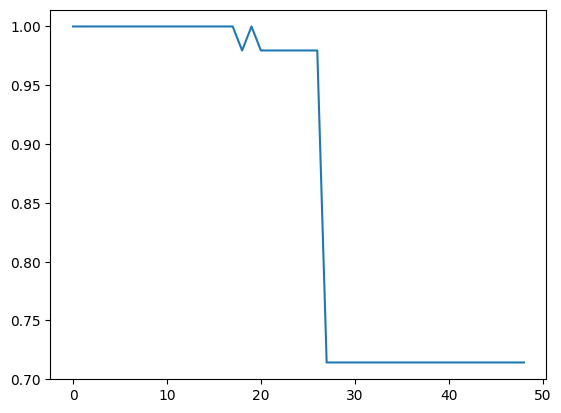

In [38]:
sns.lineplot(data=accuracies)
plt.show()